In [57]:
!pip install natsort


[notice] A new release of pip is available: 23.0.1 -> 24.1.2
[notice] To update, run: pip install --upgrade pip


In [58]:
import read_lif
import tifffile
import numpy as np
from readlif.reader import LifFile
import os
from natsort import natsorted

In [2]:
reader = LifFile('../data/flim_sirDNA_cellbrite650_zsatck.lif')

In [3]:
series0 = reader.get_image(0)
series1 = reader.get_image(1)

In [4]:
series0

'LifImage object with dimensions: Dims(x=512, y=512, z=36, t=1, m=1)'

In [5]:
series1

'LifImage object with dimensions: Dims(x=512, y=512, z=36, t=1, m=1)'

In [82]:
chosen1 = series0.get_frame(c=0, z=16)  # choose first image in the lif file
chosen2 = series0.get_frame(c=1)  # choose first image in the lif file
chosen3 = series1.get_frame()

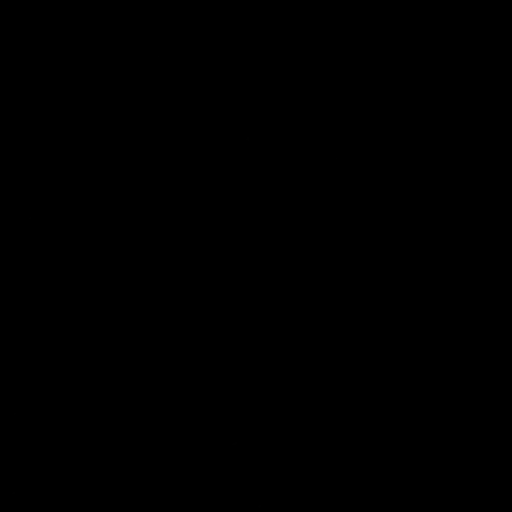

In [83]:
chosen3

### Canal 1

In [91]:
# Ruta a la carpeta con los archivos TIFF
ruta_carpeta = '../channel_3'

In [94]:
for i in range(35):
    chosen = series1.get_frame(c=0, z=i)
    tifffile.imwrite(f'{ruta_carpeta}/channel_3_{i}.tiff', chosen)

AttributeError: 'Image' object has no attribute 'get_image'

In [86]:
# Obtener una lista de todos los archivos TIFF en la carpeta
tiff_files = [f for f in os.listdir(ruta_carpeta) if f.endswith('.tiff') or f.endswith('.tif')]

In [87]:
# Ordenar la lista de archivos si es necesario
tiff_files = natsorted(tiff_files)

In [88]:
# Leer y almacenar todos los frames de los archivos TIFF
frames = []

In [89]:
for tiff_file in tiff_files:
    # Leer el archivo TIFF
    with tifffile.TiffFile(os.path.join(ruta_carpeta, tiff_file)) as tif:
        for page in tif.pages:
            frames.append(page.asarray())

In [90]:
# Guardar todos los frames en un solo archivo TIFF multipágina
tifffile.imwrite('../channel_3/channel_3.tiff', frames)

### Canal 2

In [69]:
for i in range(35):
    chosen = series0.get_frame(c=1, z=i)
    tifffile.imwrite(f'../channel_2/channel_2_{i}.tiff', chosen)

In [70]:
# Ruta a la carpeta con los archivos TIFF
ruta_carpeta = '../channel_2'

In [71]:
# Obtener una lista de todos los archivos TIFF en la carpeta
tiff_files = [f for f in os.listdir(ruta_carpeta) if f.endswith('.tiff') or f.endswith('.tif')]

In [72]:
# Ordenar la lista de archivos si es necesario
tiff_files = natsorted(tiff_files)

In [73]:
# Leer y almacenar todos los frames de los archivos TIFF
frames = []

In [74]:
for tiff_file in tiff_files:
    # Leer el archivo TIFF
    with tifffile.TiffFile(os.path.join(ruta_carpeta, tiff_file)) as tif:
        for page in tif.pages:
            frames.append(page.asarray())

In [75]:
# Guardar todos los frames en un solo archivo TIFF multipágina
tifffile.imwrite('../channel_2/channel_2.tiff', frames)